In [165]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string, emoji
from sklearn.feature_extraction.text import TfidfVectorizer
import openai

In [166]:
df = pd.read_csv("../combined_reviews.csv")
df = df[df["place_id"].str.contains("cafe")]

In [167]:
df = df[df["place_id"].str.contains("cafe")]

In [168]:
df.head()

,user_id,place_id,rating,sentiment,lang,text
1,Youssef Darjaoui,cafe_la_bella,5,positive,english,Good continuation.
2,Idriss Nouwari,in_diga_cafe_restaurant_pizzeria,5,positive,english,"Excellent service and delicious food, may God ..."
3,lahnichim matmat,cafe_le_rendezvous,3,neutral,darija,مقهى محلي تقليدي
4,zakaria toumir,cafe_big_ben,5,positive,english,Place very close to the center and the library
13,Abdellah ait ahmed Marhoum,cafe_57,5,neutral,french,Il faut le voir


In [169]:

# Count duplicates
duplicate_count = df.duplicated().sum()

if duplicate_count > 0:
    print(f"Before: {df.shape[0]}")
    print(f"{duplicate_count} duplicate rows found.")
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"After: {df.shape[0]}")
else:
    print("No duplicate values detected.")

No duplicate values detected.


In [170]:
def check_missing_values(data):
    missing = data.isnull().sum()
    missing = missing[missing > 0].sort_values()
    return missing

print(check_missing_values(df))

Series([], dtype: int64)


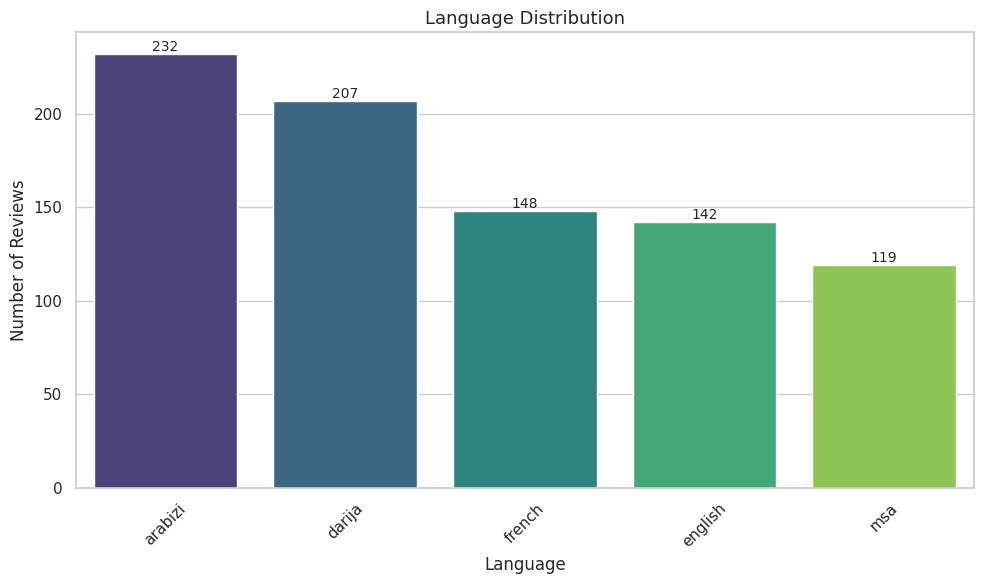

In [171]:

lang_counts = df['lang'].value_counts().reset_index()
lang_counts.columns = ['lang', 'count']

# Plot
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=lang_counts,
    x='lang',
    y='count',
    hue='lang',
    palette='viridis',
    legend=False
)

plt.title('Language Distribution', fontsize=13)
plt.xlabel('Language')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45)

for bar in ax.patches:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

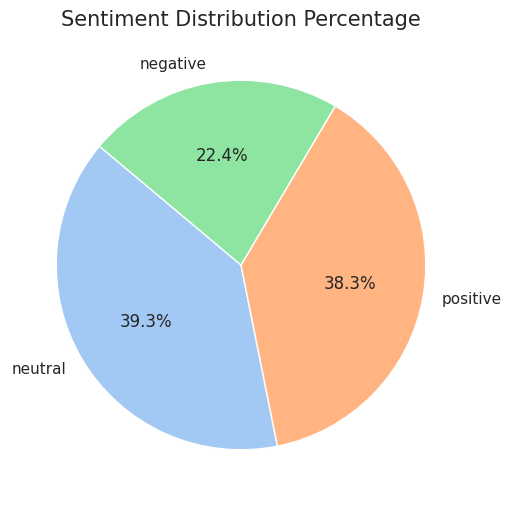

In [172]:
sentiment_counts = df['sentiment'].value_counts()

sns.set_theme(style="whitegrid")
colors = sns.color_palette('pastel')[0:len(sentiment_counts)]

plt.figure(figsize=(8, 6))
plt.pie(
    sentiment_counts, 
    labels=sentiment_counts.index, 
    autopct='%1.1f%%', # Shows the percentage on the slice
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white'} # Adds a clean border
)

plt.title('Sentiment Distribution Percentage', fontsize=15)
plt.show()

In [173]:
print("Number of coffee :", df["place_id"].nunique())

Number of coffee : 25


In [174]:
def text_cleanning(text: str) -> str:
    text = str(text).lower()

    # 1. Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

    # 2. Remove phone numbers
    text = re.sub(r'\b\+?\d[\d\s\-\(\)]{7,}\d\b', ' ', text)

    # 3. Remove emojis
    text = emoji.replace_emoji(text, replace=' ')

    # 4. Replace punctuation with spaces
    text = text.translate(
        str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    )

    # 5. Clean tokens
    tokens = text.split()
    cleaned_tokens = []
    for token in tokens:
        # Garder seulement les caractères valides
        token = re.sub(r'[^a-z\u00C0-\u017E\u0600-\u06FF0-9]', '', token)

        if not token:
            continue

        # ← NOUVEAU : supprimer les tokens purement numériques (ex: 320, 40, 5)
        # Garder uniquement si le token contient au moins une lettre
        has_letter = re.search(r'[a-z\u00C0-\u017E\u0600-\u06FF]', token)
        if has_letter:
            cleaned_tokens.append(token)

    text = ' '.join(cleaned_tokens)

    # 6. Normalize repeated characters
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 7. Collapse spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [175]:
df["text"] = df["text"].apply(text_cleanning)

In [176]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(df["text"])

def tfidf_recommendation(requete, top_n=3):
    requete_vec = tfidf_vectorizer.transform([requete])

    similarites = cosine_similarity(requete_vec, tfidf_matrix).flatten()

    top_indices = similarites.argsort()[-top_n:][::-1]
    
    print(f"---  TF-IDF Recommendations for : '{requete}' ---")
    for idx in top_indices:
        score = similarites[idx]
        print(f"[Score: {score:.3f}] {df.iloc[idx]['text']}")
    print("\n")

In [177]:
requete = "je veux un espace qui est plein d etudiant"
tfidf_recommendation(requete)

---  TF-IDF Recommendations for : 'je veux un espace qui est plein d etudiant' ---
[Score: 0.358] plein d étudiants ce qui donne envie à étudier un wifi pas mal mais le service est impeccable
[Score: 0.343] le nid est un espace normal pratique et populaire
[Score: 0.272] espace non fumeur




In [178]:
requete = "i want a space full of students"
tfidf_recommendation(requete)

---  TF-IDF Recommendations for : 'i want a space full of students' ---
[Score: 0.329] very beautiful angle of view open space
[Score: 0.216] the nest is a normal practical and popular space
[Score: 0.187] first catastrophic experience a nice restaurant crowded with people several waiters running in all directions without being effective after a quarter of an hour i called a waiter to get a menu lots of choices on the menu no one comes back to take our order when taking the order we clearly stated that we do not want any sauce in our menu after an hour of waiting a dirty table the order arrives a paella without mussels without chicken but its not bad a menu full of big sauce even though we specified we didnt want it fries barely cooked we left without eating and without any commercial gesture surely they should hire more competent staff so much investment in a nice restaurant with very poor management and low quality food even fast food does much better its really a shame




In [179]:
import dotenv
dotenv.load_dotenv()

client = openai.OpenAI()

def get_openai_embedding(text, model="text-embedding-3-small"):
    text = text.replace("\n", " ")
    response = client.embeddings.create(input=[text], model=model)
    return response.data[0].embedding

In [180]:
df["embedding"] = df["text"].apply(lambda x: get_openai_embedding(x))

In [181]:
df.head()

,user_id,place_id,rating,sentiment,lang,text,embedding
1,Youssef Darjaoui,cafe_la_bella,5,positive,english,good continuation,"[0.0496826171875, -0.01390838623046875, 0.0157..."
2,Idriss Nouwari,in_diga_cafe_restaurant_pizzeria,5,positive,english,excellent service and delicious food may god b...,"[-0.01178741455078125, -0.027435302734375, -0...."
3,lahnichim matmat,cafe_le_rendezvous,3,neutral,darija,مقهى محلي تقليدي,"[-0.04718017578125, -0.0146636962890625, 0.021..."
4,zakaria toumir,cafe_big_ben,5,positive,english,place very close to the center and the library,"[-0.045989990234375, -0.03863525390625, 0.0217..."
13,Abdellah ait ahmed Marhoum,cafe_57,5,neutral,french,il faut le voir,"[-0.00830078125, 0.0274658203125, -0.029129028..."


In [186]:
import numpy as np
corpus_embeddings_matrix = np.array(df["embedding"].tolist())

In [187]:
def openai_recommendation(requete, top_n=3):
    requete_vec = get_openai_embedding(requete)
    requete_vec_2d = np.array(requete_vec).reshape(1, -1)
    similarites = cosine_similarity(requete_vec_2d, corpus_embeddings_matrix).flatten()
    top_indices = similarites.argsort()[-top_n:][::-1]
    
    print(f"--- OpenAI Recommendations for : '{requete}' ---")
    for idx in top_indices:
        score = similarites[idx]
        print(f"[Score: {score:.3f}] {df.iloc[idx]['text']}")
    print("\n")

In [188]:
requete = "je veux un espace qui est plein d etudiant"
openai_recommendation(requete)

--- OpenAI Recommendations for : 'je veux un espace qui est plein d etudiant' ---
[Score: 0.575] plein d étudiants de l ensa qui bossent sérieusement ça motive vraiment à ouvrir ses cours ambiance studieuse au top
[Score: 0.565] plein d étudiants ce qui donne envie à étudier un wifi pas mal mais le service est impeccable
[Score: 0.454] espace non fumeur




In [189]:
requete = "i want a space full of students"
openai_recommendation(requete, top_n=3)

--- OpenAI Recommendations for : 'i want a space full of students' ---
[Score: 0.446] plein d étudiants de l ensa qui bossent sérieusement ça motive vraiment à ouvrir ses cours ambiance studieuse au top
[Score: 0.393] plein d étudiants ce qui donne envie à étudier un wifi pas mal mais le service est impeccable
[Score: 0.345] place very close to the center and the library




In [197]:
dfs_per_service = {service: data for service, data in df.groupby('place_id')}

In [224]:
from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer


umap_model = UMAP(n_neighbors=5, n_components=5, min_dist=0.0, metric="cosine", random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=3, min_samples=2, metric="euclidean", prediction_data=True)

stop_words = [
    "café", "cafe", "coffee", "9ehwa", "9ahwa", "qahwa", "قهوى", "قهوة", 
    "service", "serveur", "serveuse", "place", "endroit", "بلاصة",
    "vraiment", "rien", "qu", "bien", "non", "très", "trop", "beaucoup", 
    "very", "too", "much", "really", "yes", "oui", "c'est", "c", "d", "l", "m", "n", "s", "t", "y",
    "li", "chi", "gha", "had", "hadchi", "kayn", "kayna", "makaynch", 
    "fach", "mnin", "bzaf", "bezaf", "chwiya", "wla", "wela", "ou", 
    "u", "o", "wa", "f", "b", "m3a", "3la", "dyal", "dial", "ta3", 
    "nta", "nti", "hwa", "hya", "7na", "homa", "hna", "l", "lli", 
    "dak", "dik", "hadik", "hadak", "mn", "men", "3nd", "and", "3ndak", 
    "andak", "bash", "bach", "3lash", "alash", "kifash", "kifach", 
    "achno", "chno", "shno", "chnu", "rah", "ra", "dar", "darna", "dir",
    "اللي", "شي", "غا", "هاد", "هادشي", "كاين", "كاينة", "مكاينش", 
    "فاش", "منين", "بزاف", "شوية", "ولا", "و", "ف", "ب", "مع", "على", 
    "ديال", "تاع", "نتا", "نتي", "هو", "هي", "حنا", "هما", "هنا", "ل", 
    "داك", "ديك", "هاديك", "هاداك", "من", "عند", "باش", "علاش", 
    "كيفاش", "اشنو", "شنو", "راه", "را"
]


vectorizer = CountVectorizer(stop_words=stop_words, token_pattern=r'[a-zA-ZÀ-ÿ\u0600-\u06FF0-9]{2,}')

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    nr_topics=4
)

In [225]:
topics_per_service = {}

for service_name, df_service in dfs_per_service.items():
    if len(df_service) < 15:
        continue

    docs_service = df_service["text"].tolist()
    
    embeddings_service = np.array(df_service["embedding"].tolist())
    
    try:

        topics, probs = topic_model.fit_transform(docs_service, embeddings=embeddings_service)

        df_service = df_service.copy()
        df_service["topic"] = topics
        
        info_topics = topic_model.get_topic_info()

        topics_per_service[service_name] = {
            "donnees_mises_a_jour": df_service,
            "resume_topics": info_topics,
        }

    except Exception as e:
        print(f"Errror")

In [248]:
def hybrid_recommendations(request, topics_per_service, dfs_par_service):
    request_embedding = get_openai_embedding(request)
    request_embedding_2d = np.array(request_embedding).reshape(1, -1)
    
    max_similarity = -1000
    best_service = None

    for service_name, df in dfs_par_service.items():
        if len(df) < 15:
            continue

        dominant_sentiment = df["sentiment"].mode()[0]
        sentiment_score = 1 if dominant_sentiment == "positive" else 0
        
        topics_lists = topics_per_service[service_name]["resume_topics"]["Representation"].tolist()
        all_topic_keywords = " ".join([" ".join(words) for words in topics_lists])

        topic_embedding = get_openai_embedding(all_topic_keywords)
        topic_embedding_2d = np.array(topic_embedding).reshape(1, -1)
        
        topic_similarity = cosine_similarity(request_embedding_2d, topic_embedding_2d)[0][0]

        service_embeddings_matrix = np.array(df["embedding"].tolist())

        text_similarities = cosine_similarity(request_embedding_2d, service_embeddings_matrix).flatten()

        best_text_similarity = text_similarities.max()

        combined = (0.75 * best_text_similarity) + (0.10 * topic_similarity) + (0.05 * sentiment_score)

        if combined > max_similarity:
            max_similarity = combined
            best_service = service_name
            
    return best_service, max_similarity

In [261]:
test = "J'aimerais trouver un espace ou je peux trouver autres étudiants pour pouvoir réviser avec mes amis."

best_service, score = hybrid_recommendations(test, topics_per_service, dfs_per_service)

In [264]:
print(f"Best service: {best_service}")

Best service: cafe__genova
